Random Forest - Test Accuracy: 0.9345
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       610
           1       0.90      0.93      0.92       505
           2       0.92      0.94      0.93       339
           3       0.95      0.94      0.94       546

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



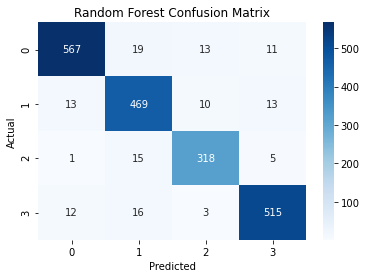


Cross-validation scores: [0.9225   0.915    0.916875 0.9175   0.915   ]
Mean cross-validation accuracy: 0.9174


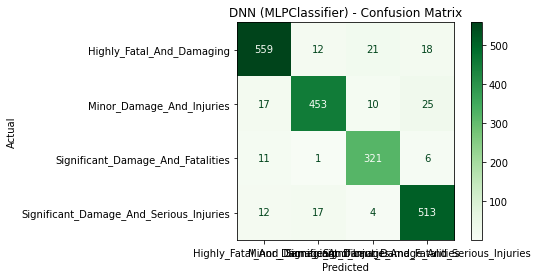

DNN Accuracy: 0.9230
DNN Precision: 0.9235
DNN Recall: 0.9230
DNN F1 Score: 0.9230

DNN - TP, FP, FN, TN per class:
Class 'Highly_Fatal_And_Damaging': TP=559, FP=40, FN=51, TN=1350
Class 'Minor_Damage_And_Injuries': TP=453, FP=30, FN=52, TN=1465
Class 'Significant_Damage_And_Fatalities': TP=321, FP=35, FN=18, TN=1626
Class 'Significant_Damage_And_Serious_Injuries': TP=513, FP=49, FN=33, TN=1405


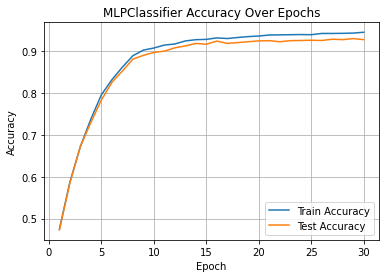

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report

# << Load and preprocess dataset >>
df = pd.read_csv('/Users/zm/Desktop/Airplane accidents severity.csv')

label_encoder = LabelEncoder()
df['Severity_encoded'] = label_encoder.fit_transform(df['Severity'])

X = df.drop(columns=['Severity', 'Severity_encoded', 'Accident_ID'])
y = df['Severity_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# << Random Forest Model >>
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest - Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# << DNN Model Training >>
dnn_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                          max_iter=300, batch_size=32, random_state=42)
dnn_model.fit(X_train_scaled, y_train)

# << Cross-Validation for DNN >>
dnn_cv_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                             solver='adam', max_iter=300, batch_size=32, random_state=42)
cv_scores = cross_val_score(dnn_cv_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-validation scores:", cv_scores)
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")

# << DNN Evaluation >>
y_pred_dnn = dnn_model.predict(X_test_scaled)
labels = label_encoder.classes_
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

# <<Confusion Matrix Plot>>
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dnn, display_labels=labels)
disp.plot(cmap='Greens')
plt.title("DNN (MLPClassifier) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <<Accuracy, Precision, Recall, F1>>
acc_dnn = accuracy_score(y_test, y_pred_dnn)
precision_dnn = precision_score(y_test, y_pred_dnn, average='weighted')
recall_dnn = recall_score(y_test, y_pred_dnn, average='weighted')
f1_dnn = f1_score(y_test, y_pred_dnn, average='weighted')

print(f"DNN Accuracy: {acc_dnn:.4f}")
print(f"DNN Precision: {precision_dnn:.4f}")
print(f"DNN Recall: {recall_dnn:.4f}")
print(f"DNN F1 Score: {f1_dnn:.4f}")

# <<TP, FP, FN, TN per class>>
print("\nDNN - TP, FP, FN, TN per class:")
for i, label in enumerate(labels):
    TP = cm_dnn[i, i]
    FP = cm_dnn[:, i].sum() - TP
    FN = cm_dnn[i, :].sum() - TP
    TN = cm_dnn.sum() - (TP + FP + FN)
    print(f"Class '{label}': TP={TP}, FP={FP}, FN={FN}, TN={TN}")

# << Accuracy Visualization >>
train_scores = []
test_scores = []

for i in range(1, 31):
    model_temp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=i, solver='adam', activation='relu', random_state=42, warm_start=True)
    model_temp.fit(X_train_scaled, y_train)
    train_scores.append(model_temp.score(X_train_scaled, y_train))
    test_scores.append(model_temp.score(X_test_scaled, y_test))

plt.plot(range(1, 31), train_scores, label='Train Accuracy')
plt.plot(range(1, 31), test_scores, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLPClassifier Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()
